In [3]:
from google.colab import drive
drive.mount('/content/drive')
import zipfile
import os

zip_path = "/content/drive/MyDrive/dataset.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extraído correctamente")

print(os.listdir(extract_path))

MessageError: Error: credential propagation was unsuccessful

Imagen original: (4080, 3072, 3)
Guardada: /content/datasheet/pos_8/ruleta_1_946744.png
Guardada: /content/datasheet/pos_8/ruleta_2_640480.png
Guardada: /content/datasheet/pos_8/ruleta_3_45865.png
Guardada: /content/datasheet/pos_8/ruleta_4_493407.png
Guardada: /content/datasheet/pos_8/ruleta_5_523665.png


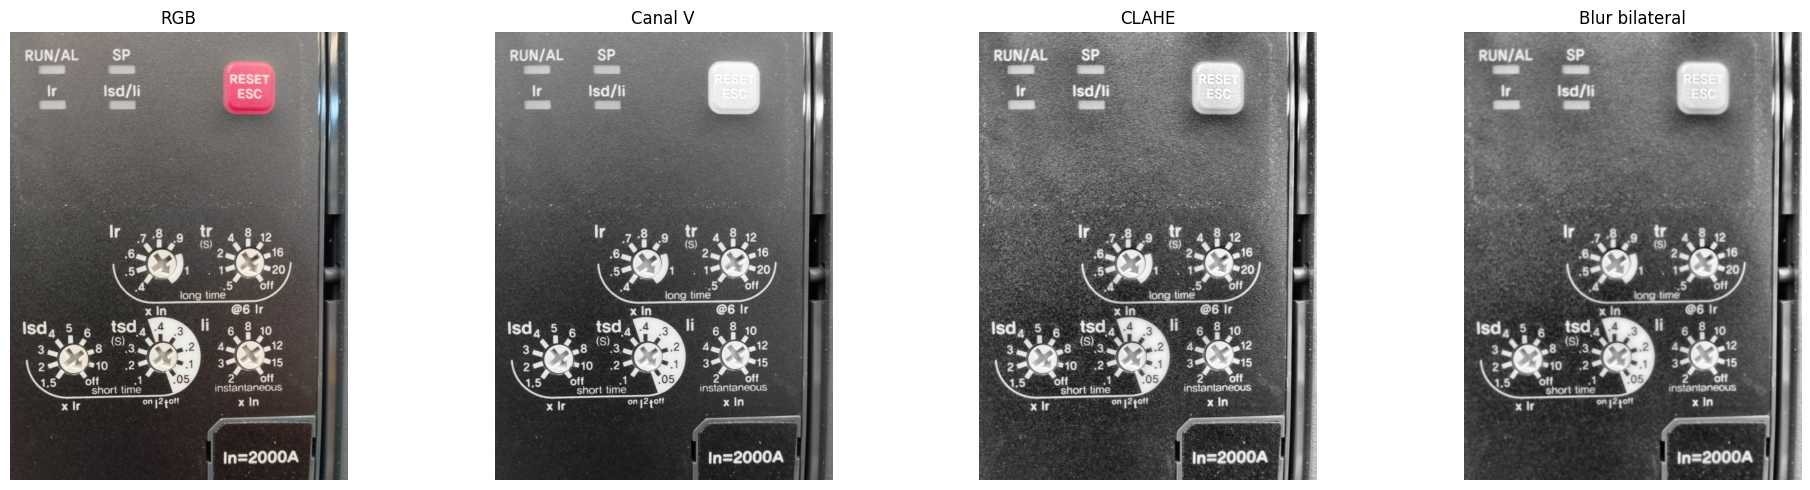

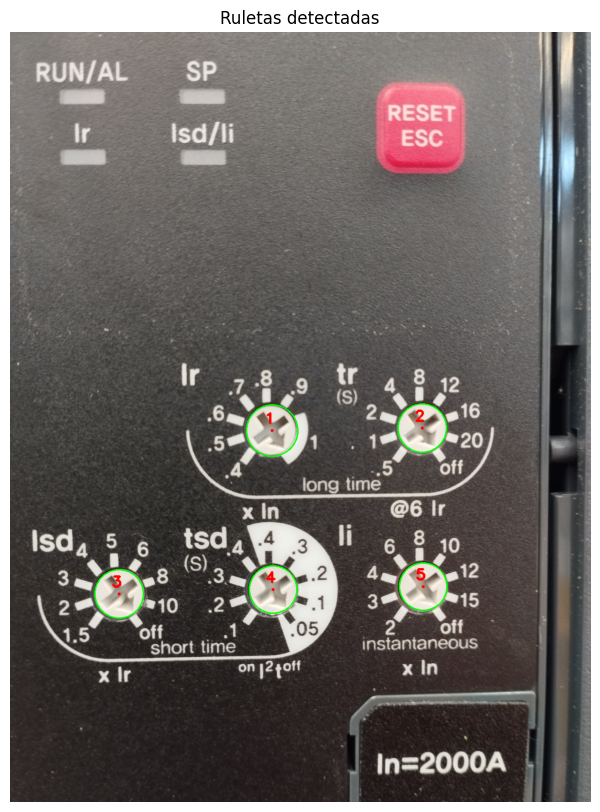

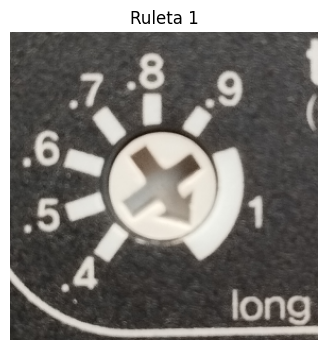

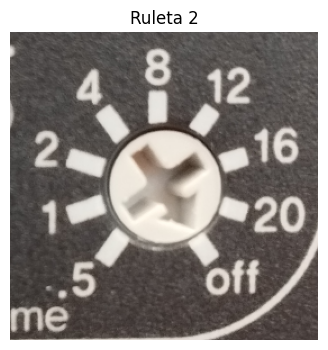

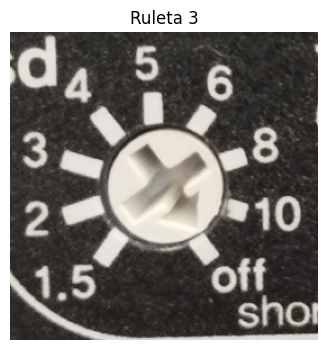

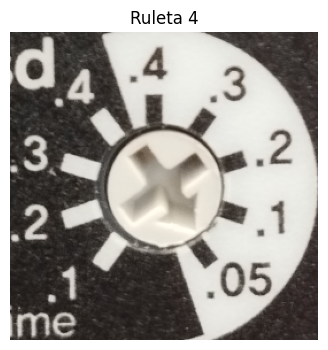

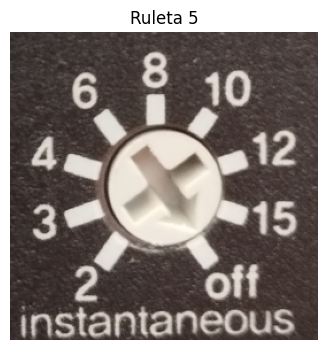

In [ ]:
# ============================================================
# PROCESAR Y GUARDAR DATASET
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================================
# CONFIGURACIÓN
# ============================================================

# imagen a procesar
image_path = "/content/Posiciones/Pos8/Pos8 (31).jpg"

# posición real
posicion_real = 8

# dataset destino
dataset_path = "/content/datasheet"

# guardar recortes
guardar = True

# mostrar resultados
mostrar = True

# ============================================================
# CREAR CARPETA DESTINO
# ============================================================

save_folder = f"{dataset_path}/pos_{posicion_real}"

os.makedirs(save_folder, exist_ok=True)

# ============================================================
# CARGA DE IMAGEN
# ============================================================

img = cv2.imread(image_path)

if img is None:
    raise ValueError(f"Error cargando imagen: {image_path}")

print("Imagen original:", img.shape)

# ============================================================
# NORMALIZACIÓN DE TAMAÑO
# ============================================================

target_width = 1200

h, w = img.shape[:2]

scale = target_width / w

new_w = target_width
new_h = int(h * scale)

img = cv2.resize(
    img,
    (new_w, new_h),
    interpolation=cv2.INTER_AREA
)

# print("Imagen redimensionada:", img.shape)

# ============================================================
# CONVERSIÓN COLOR
# ============================================================

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

v = hsv[:,:,2]

# ============================================================
# NORMALIZACIÓN ILUMINACIÓN
# ============================================================

clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8,8)
)

v_clahe = clahe.apply(v)

# ============================================================
# SUAVIZADO
# ============================================================

blur = cv2.bilateralFilter(v_clahe, 9, 75, 75)

# ============================================================
# DETECCIÓN DE RULETAS
# ============================================================

circles = cv2.HoughCircles(
    blur,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=100,
    param1=120,
    param2=35,
    minRadius=40,
    maxRadius=60
)

output = img_rgb.copy()

ruletas = []

# ============================================================
# PROCESAMIENTO CÍRCULOS
# ============================================================

if circles is not None:

    circles = np.round(circles[0]).astype(int)

    # print("Círculos detectados:", len(circles))

    # ========================================================
    # FILTRAR 5 MÁS CENTRADOS
    # ========================================================

    xs = np.array([c[0] for c in circles])
    ys = np.array([c[1] for c in circles])

    cx = np.mean(xs)
    cy = np.mean(ys)

    errores = []

    for x, y, r in circles:

        err = (x - cx)**2 + (y - cy)**2

        errores.append((err, (x, y, r)))

    errores.sort(key=lambda e: e[0])

    circles_filtrados = [e[1] for e in errores[:5]]

    # ========================================================
    # ORDENACIÓN POR FILAS
    # ========================================================

    circles_filtrados = sorted(
        circles_filtrados,
        key=lambda c: c[1]
    )

    filas = []

    tolerancia_y = 80

    for circle in circles_filtrados:

        x, y, r = circle

        colocado = False

        for fila in filas:

            y_media = np.mean([c[1] for c in fila])

            if abs(y - y_media) < tolerancia_y:

                fila.append(circle)

                colocado = True

                break

        if not colocado:

            filas.append([circle])

    filas.sort(
        key=lambda fila: np.mean([c[1] for c in fila])
    )

    circles_sorted = []

    for fila in filas:

        fila_ordenada = sorted(
            fila,
            key=lambda c: c[0]
        )

        circles_sorted.extend(fila_ordenada)

    # ========================================================
    # RECORTE Y GUARDADO
    # ========================================================

    for i, (x, y, r) in enumerate(circles_sorted):

        # círculo
        cv2.circle(
            output,
            (x, y),
            r,
            (0,255,0),
            2
        )

        # centro
        cv2.circle(
            output,
            (x, y),
            3,
            (255,0,0),
            -1
        )

        # número
        cv2.putText(
            output,
            str(i+1),
            (x-15, y-15),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.0,
            (255,0,0),
            3
        )

        # ====================================================
        # RECORTE
        # ====================================================

        buffer = int(r * 1.75)

        x1 = max(0, x-r-buffer)
        y1 = max(0, y-r-buffer)

        x2 = min(img.shape[1], x+r+buffer)
        y2 = min(img.shape[0], y+r+buffer)

        cropped_ruleta = img_rgb[y1:y2, x1:x2]

        # ====================================================
        # VALIDACIÓN
        # ====================================================

        if (
            cropped_ruleta.shape[0] > 0 and
            cropped_ruleta.shape[1] > 0
        ):

            ruletas.append(cropped_ruleta)

            # ================================================
            # GUARDAR
            # ================================================

            if guardar:

                filename = (
                    f"ruleta_{i+1}_"
                    f"{np.random.randint(1000000)}.png"
                )

                save_path = os.path.join(
                    save_folder,
                    filename
                )

                cv2.imwrite(
                    save_path,
                    cv2.cvtColor(
                        cropped_ruleta,
                        cv2.COLOR_RGB2BGR
                    )
                )

                print("Guardada:", save_path)

else:

    print("No se detectaron círculos")

# ============================================================
# VISUALIZACIÓN
# ============================================================

if mostrar:

    # ========================================================
    # PIPELINE
    # ========================================================

    fig, axes = plt.subplots(1,4, figsize=(20,5))

    axes[0].imshow(img_rgb)
    axes[0].set_title("RGB")

    axes[1].imshow(v, cmap='gray')
    axes[1].set_title("Canal V")

    axes[2].imshow(v_clahe, cmap='gray')
    axes[2].set_title("CLAHE")

    axes[3].imshow(blur, cmap='gray')
    axes[3].set_title("Blur bilateral")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    # ========================================================
    # RULETAS DETECTADAS
    # ========================================================

    plt.figure(figsize=(10,10))

    plt.imshow(output)

    plt.title("Ruletas detectadas")

    plt.axis("off")

    plt.show()

    # ========================================================
    # RECORTES
    # ========================================================

    for i, ruleta in enumerate(ruletas):

        plt.figure(figsize=(4,4))

        plt.imshow(ruleta)

        plt.title(f"Ruleta {i+1}")

        plt.axis("off")

        plt.show()

# ============================================================
# RESUMEN
# ============================================================
  print("\n===================================")
  print("PROCESAMIENTO COMPLETADO")
  print("===================================")

  print("Imagen procesada:", image_path)
  print("Posición:", posicion_real)
  print("Ruletas guardadas:", len(ruletas))
  print("Destino:", save_folder)

In [ ]:
# ============================================================
# BLOQUE 3 — ENTRENAMIENTO MEJORADO
# ============================================================

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# ============================================================
# CONFIGURACIÓN
# ============================================================

dataset_path = "/content/dataset"

# mayor resolución
img_size = 384

batch_size = 16

# entrenamiento inicial
epochs = 30

# fine tuning
fine_tune_epochs = 20

# ============================================================
# DATA AUGMENTATION (MUY SUAVE)
# ============================================================

# IMPORTANTE:
# eliminamos rotaciones y shifts
# porque el problema es angular

train_datagen = ImageDataGenerator(

    rescale=1./255,

    validation_split=0.2,

    brightness_range=[0.95, 1.05]
)

# ============================================================
# TRAIN GENERATOR
# ============================================================

train_generator = train_datagen.flow_from_directory(

    dataset_path,

    target_size=(img_size, img_size),

    batch_size=batch_size,

    class_mode='categorical',

    subset='training',

    shuffle=True
)

# ============================================================
# VALIDATION GENERATOR
# ============================================================

val_generator = train_datagen.flow_from_directory(

    dataset_path,

    target_size=(img_size, img_size),

    batch_size=batch_size,

    class_mode='categorical',

    subset='validation',

    shuffle=False
)

# ============================================================
# CLASES
# ============================================================

class_names = train_generator.class_indices

num_classes = len(class_names)

print("\nClases detectadas:")
print(class_names)

# ============================================================
# MODELO BASE
# ============================================================

base_model = MobileNetV2(

    input_shape=(img_size, img_size, 3),

    include_top=False,

    weights='imagenet'
)

# ============================================================
# CONGELAR MODELO BASE
# ============================================================

base_model.trainable = False

# ============================================================
# MODELO FINAL
# ============================================================

model = models.Sequential([

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation='relu'),

    layers.Dropout(0.4),

    layers.Dense(num_classes, activation='softmax')
])

# ============================================================
# COMPILACIÓN INICIAL
# ============================================================

model.compile(

    optimizer=tf.keras.optimizers.Adam(1e-3),

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

# ============================================================
# RESUMEN
# ============================================================

model.summary()

# ============================================================
# CALLBACKS
# ============================================================

early_stop = tf.keras.callbacks.EarlyStopping(

    monitor='val_loss',

    patience=5,

    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.5,

    patience=2,

    verbose=1
)

# ============================================================
# ENTRENAMIENTO INICIAL
# ============================================================

print("\n================================================")
print("ENTRENAMIENTO INICIAL")
print("================================================\n")

history = model.fit(

    train_generator,

    validation_data=val_generator,

    epochs=epochs,

    callbacks=[early_stop, reduce_lr]
)

# ============================================================
# FINE TUNING
# ============================================================

print("\n================================================")
print("FINE TUNING")
print("================================================\n")

# descongelar modelo base
base_model.trainable = True

# congelar primeras capas
for layer in base_model.layers[:100]:
    layer.trainable = False

# recompilar con learning rate pequeño
model.compile(

    optimizer=tf.keras.optimizers.Adam(1e-5),

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

# continuar entrenamiento
history_fine = model.fit(

    train_generator,

    validation_data=val_generator,

    epochs=fine_tune_epochs,

    callbacks=[early_stop, reduce_lr]
)

# ============================================================
# GUARDAR MODELO
# ============================================================

model.save("/content/modelo_ruletas_mobilenet.keras")

print("\nModelo guardado correctamente")

# ============================================================
# COMBINAR HISTORIALES
# ============================================================

acc = history.history['accuracy'] + history_fine.history['accuracy']

val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']

loss = history.history['loss'] + history_fine.history['loss']

val_loss = history.history['val_loss'] + history_fine.history['val_loss']

epochs_range = range(len(acc))

# ============================================================
# GRÁFICAS
# ============================================================

plt.figure(figsize=(14,5))

# ============================================================
# ACCURACY
# ============================================================

plt.subplot(1,2,1)

plt.plot(epochs_range, acc, label='Train Accuracy')

plt.plot(epochs_range, val_acc, label='Validation Accuracy')

plt.legend(loc='lower right')

plt.title('Accuracy')

# ============================================================
# LOSS
# ============================================================

plt.subplot(1,2,2)

plt.plot(epochs_range, loss, label='Train Loss')

plt.plot(epochs_range, val_loss, label='Validation Loss')

plt.legend(loc='upper right')

plt.title('Loss')

plt.show()

# ============================================================
# EVALUACIÓN FINAL
# ============================================================

val_loss, val_acc = model.evaluate(val_generator)

print(f"\nValidation Accuracy Final: {val_acc:.4f}")

print(f"Validation Loss Final: {val_loss:.4f}")

Found 1419 images belonging to 9 classes.
Found 348 images belonging to 9 classes.

Clases detectadas:
{'pos_0': 0, 'pos_1': 1, 'pos_2': 2, 'pos_3': 3, 'pos_4': 4, 'pos_5': 5, 'pos_6': 6, 'pos_7': 7, 'pos_8': 8}


/tmp/ipykernel_664/783163813.py:100: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 12, 12, 1280)   │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,233 (9.87 MB)

 Trainable params: 330,249 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


ENTRENAMIENTO INICIAL

Epoch 1/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 264s 3s/step - accuracy: 0.2777 - loss: 2.0420 - val_accuracy: 0.3851 - val_loss: 1.8004 - learning_rate: 0.0010
Epoch 2/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 209s 2s/step - accuracy: 0.5081 - loss: 1.5091 - val_accuracy: 0.5690 - val_loss: 1.3832 - learning_rate: 0.0010
Epoch 3/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 264s 2s/step - accuracy: 0.6209 - loss: 1.1797 - val_accuracy: 0.6293 - val_loss: 1.1759 - learning_rate: 0.0010
Epoch 4/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 210s 2s/step - accuracy: 0.7047 - loss: 0.9602 - val_accuracy: 0.7874 - val_loss: 0.9341 - learning_rate: 0.0010
Epoch 5/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 220s 2s/step - accuracy: 0.7703 - loss: 0.7697 - val_accuracy: 0.7299 - val_loss: 0.8141 - learning_rate: 0.0010
Epoch 6/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 208s 2s/step - accuracy: 0.7984 - loss: 0.6752 - val_accuracy: 0.8333 - val_loss: 0.6273 - learning_rate: 0.0010
Epoch 7/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 219s 2s/step - accuracy: 0.8337 

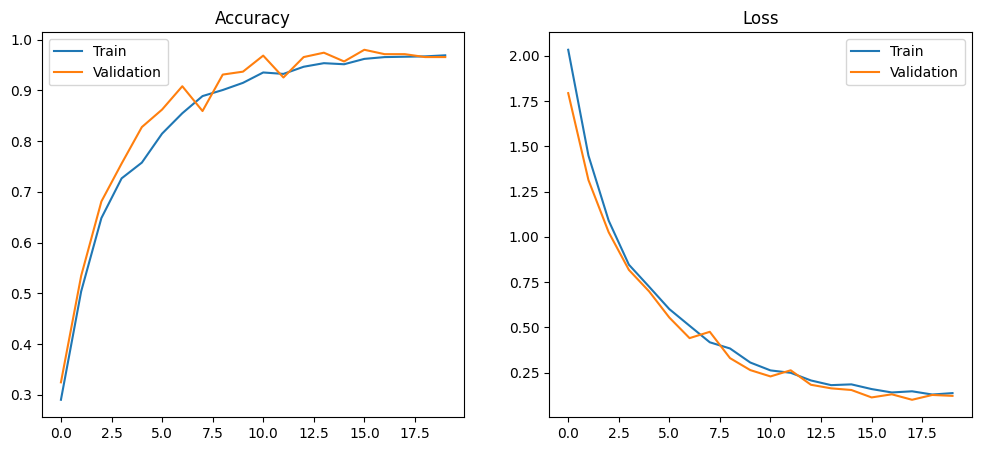

In [ ]:
# ============================================================
# BLOQUE 4 — GRÁFICAS DE ENTRENAMIENTO
# ============================================================

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12,5))

# ACCURACY
plt.subplot(1,2,1)

plt.plot(epochs_range, acc, label='Train')
plt.plot(epochs_range, val_acc, label='Validation')

plt.title('Accuracy')
plt.legend()

# LOSS
plt.subplot(1,2,2)

plt.plot(epochs_range, loss, label='Train')
plt.plot(epochs_range, val_loss, label='Validation')

plt.title('Loss')
plt.legend()

plt.show()

In [ ]:
# ============================================================
# BLOQUE 5 — PREDICCIÓN
# ============================================================

from tensorflow.keras.preprocessing import image

# ============================================================
# IMAGEN A PREDECIR
# ============================================================

test_image_path = "/content/dataset/pos_8/ejemplo.png"

img_test = image.load_img(
    test_image_path,
    target_size=(128,128)
)

img_array = image.img_to_array(img_test)

img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

# ============================================================
# PREDICCIÓN
# ============================================================

prediction = model.predict(img_array)

predicted_class = np.argmax(prediction)

print("Predicción:", predicted_class)

# ============================================================
# MOSTRAR IMAGEN
# ============================================================

plt.imshow(img_test)

plt.title(f"Predicción: pos_{predicted_class}")

plt.axis("off")

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/dataset/pos_8/ejemplo.png'

In [ ]:
import cv2
import os

dataset_path = "/content/dataset"

scores = []

for class_name in os.listdir(dataset_path):

    class_folder = os.path.join(dataset_path, class_name)

    if not os.path.isdir(class_folder):
        continue

    for file_name in os.listdir(class_folder):

        path = os.path.join(class_folder, file_name)

        img = cv2.imread(path)

        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        score = cv2.Laplacian(gray, cv2.CV_64F).var()

        scores.append((score, path))

scores = sorted(scores)

for score, path in scores[:30]:
    print(f"{score:.2f} -> {path}")

123.23 -> /content/dataset/pos_4/ruleta_2_383243.png
133.67 -> /content/dataset/pos_6/ruleta_1_599570.png
135.61 -> /content/dataset/pos_1/ruleta_1_859892.png
141.70 -> /content/dataset/pos_1/ruleta_2_463933.png
143.64 -> /content/dataset/pos_0/ruleta_1_629685.png
146.21 -> /content/dataset/pos_5/ruleta_2_803950.png
153.51 -> /content/dataset/pos_0/ruleta_2_810615.png
158.51 -> /content/dataset/pos_5/ruleta_1_650908.png
161.35 -> /content/dataset/pos_4/ruleta_1_55565.png
162.48 -> /content/dataset/pos_4/ruleta_2_836668.png
170.32 -> /content/dataset/pos_4/ruleta_2_687400.png
171.18 -> /content/dataset/pos_6/ruleta_2_197371.png
178.60 -> /content/dataset/pos_5/ruleta_2_509709.png
187.01 -> /content/dataset/pos_1/ruleta_4_697603.png
190.48 -> /content/dataset/pos_4/ruleta_1_233324.png
193.30 -> /content/dataset/pos_6/ruleta_1_316500.png
199.34 -> /content/dataset/pos_4/ruleta_5_927947.png
201.62 -> /content/dataset/pos_2/ruleta_1_917890.png
206.58 -> /content/dataset/pos_4/ruleta_5_40528

In [ ]:
import cv2
import os

dataset_path = "/content/dataset"

threshold = 80

removed = 0

for class_name in os.listdir(dataset_path):

    class_folder = os.path.join(dataset_path, class_name)

    if not os.path.isdir(class_folder):
        continue

    for file_name in os.listdir(class_folder):

        path = os.path.join(class_folder, file_name)

        img = cv2.imread(path)

        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # medida de nitidez
        score = cv2.Laplacian(gray, cv2.CV_64F).var()

        # si está borrosa
        if score < threshold:

            os.remove(path)

            removed += 1

            print(f"Eliminada: {path} | blur score={score:.2f}")

print(f"\nTotal eliminadas: {removed}")


Total eliminadas: 0
